# MODULE 2: INTERPRETABLE MODELS
## 2.1 LINEAR MODELS INTERPRETATION




### 2.1.1 LINEAR REGRESSION (nice one)

In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from scipy import stats

In [2]:
df = pd.read_csv('output-simpleXY-1.csv')
df.info()
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       30 non-null     float64
 1   y       30 non-null     float64
dtypes: float64(2)
memory usage: 608.0 bytes


,x,y
0,0.344545,0.243370
1,0.698927,0.803603
2,0.087992,0.121807
3,0.689751,0.801558
4,0.642911,0.647847


In [3]:
## BUILD THE LINEAR REGRESSION MODEL

# 1. Prepare data

# Separate features (X) and target variable (y)
X = df[['x']]  # feature columns
y = df['y']  # target column




# 2. Create and train the model
model = LinearRegression()
model.fit(X, y)
betas = model.coef_
beta_0 = model.intercept_
residuals = y-model.predict(X)

print('Beta_0: ', beta_0, "(intercept)")
print('Beta_1: ', betas)
print('Epsilon (error): ', residuals)


Beta_0:  0.0004709888497087533 (intercept)
Beta_1:  [0.98152897]
Epsilon (error):  0    -0.095282
1     0.117115
2     0.034970
3     0.124076
4     0.016340
5    -0.140935
6    -0.096411
7     0.115571
8    -0.046596
9     0.201008
10    0.075031
11    0.013613
12    0.134998
13    0.034970
14   -0.137720
15    0.223416
16   -0.026701
17    0.027657
18   -0.379153
19    0.022518
20   -0.012357
21   -0.003109
22   -0.140576
23   -0.039295
24    0.107361
25   -0.083400
26    0.056115
27    0.002384
28   -0.140576
29    0.034970
Name: y, dtype: float64


### 2.2.2 INTERPRETING LINEAR REGRESSION


### Visualization

c:\Users\gilpe\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


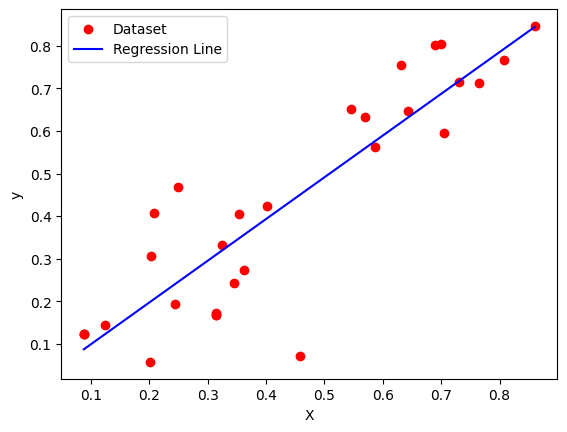

In [4]:
# Generate predictions for visualization
x_range = np.linspace(X.min(), X.max(), 100)  # Create a range of x values
y_pred = model.predict(x_range.reshape(-1, 1))  # Predict y values

# Plot the data points
plt.scatter(X, y, color='red', label='Dataset')

# Plot the regression line
plt.plot(x_range, y_pred, color='blue', label='Regression Line')

# Add labels and legend
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

# Show the plot
plt.show()

### Standard Error

In [5]:
# Calculate the standard error of the regression
n = len(y)  # Number of observations
p = X.shape[1]  # Number of predictors (features)
standard_error = np.sqrt(np.sum(residuals**2) / (n - p - 1))

print("SE", standard_error)

type(standard_error) #series

SE 0.12374289984221588


numpy.float64

### Statistic |t| - value

In [ ]:
# Calculate standard errors of the coefficients
# Assuming X is standardized (mean=0, variance=1) for simplicity
# If not, you'll need to calculate the variance-covariance matrix of the coefficients
coef_se = standard_error / np.sqrt(n)

# Calculate t-statistics
t_statistics = betas / coef_se

print("|t|", t_statistics)
type(t_statistics) #series

|t| x    10.107023
dtype: float64


pandas.core.series.Series

###Statistic p-value

In [7]:
# Calculate p-values
p_values = 2 * (1 - stats.t.cdf(np.abs(t_statistics), df=n - p - 1))

print('p-values',p_values)
type(p_values) #series


p-values [7.60507213e-11]


numpy.ndarray

### All statistics together

In [8]:
summary = pd.DataFrame()
summary['Weight'] = np.array(betas)
summary['SE'] = np.array(coef_se)
summary['|t|'] = np.array(t_statistics)
summary['p-value'] = p_values
summary

,Weight,SE,|t|,p-value
0,0.981529,0.097114,10.107023,7.605072e-11
